In [3]:
# import sys
# !{sys.executable} -m pip install scikit-surprise

In [4]:
# import sys
# !conda install --yes --prefix {sys.prefix} pandas matplotlib numpy scipy seaborn scikit-learn

In [8]:
import pandas as pd

# Load the data
users = pd.read_csv('../data/filtered/FilteredUsers.csv')
books = pd.read_csv('../data/filtered/FilteredBooks.csv')
ratings = pd.read_csv('../data/filtered/FilteredRatings.csv')

# Display the first few rows of each dataset
print(books.head())
print(users.head())
print(ratings.head())

         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author  Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford                 2002     Oxford University Press   
1  Richard Bruce Wright                 2001       HarperFlamingo Canada   
2          Carlo D'Este                 1991             HarperPerennial   
3      Gina Bari Kolata                 1999        Farrar Straus Giroux   
4       E. J. W. Barber                 1999  W. W. Norton &amp; Company   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http://images.amazo

In [15]:
# Check for missing values
print(books.isnull().sum(), "\n")
print(users.isnull().sum(), "\n")
print(ratings.isnull().sum(), "\n")

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            0
dtype: int64 

User-ID          0
Location         0
Age         110762
dtype: int64 

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64 



In [11]:
# Check for duplicate values
print(books.duplicated().sum())
print(users.duplicated().sum())
print(ratings.duplicated().sum())

0
0
0


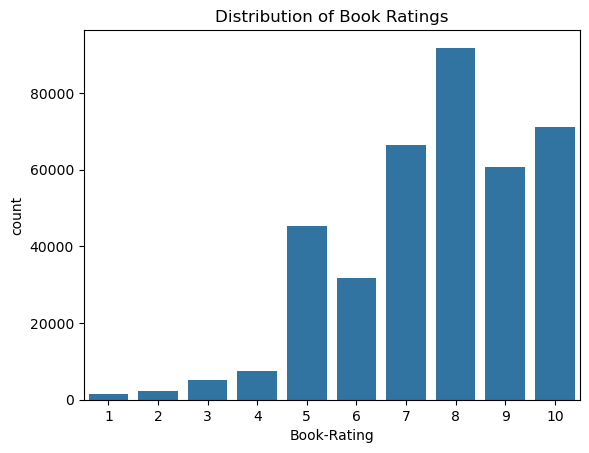

Most rated books:
 ISBN
0316666343    706
0971880107    581
0385504209    487
0312195516    383
0060928336    320
059035342X    312
0142001740    306
0446672211    295
044023722X    281
0452282152    278
Name: count, dtype: int64
Active users:
 User-ID
11676     6943
98391     5691
189835    1899
153662    1845
23902     1180
235105    1020
76499     1012
171118     962
16795      959
248718     941
Name: count, dtype: int64


In [9]:
# Distribution of ratings
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Book-Rating', data=ratings)
plt.title('Distribution of Book Ratings')
plt.show()

# Most rated books
most_rated_books = ratings['ISBN'].value_counts().head(10)
print("Most rated books:\n", most_rated_books)

# Active users
active_users = ratings['User-ID'].value_counts().head(10)
print("Active users:\n", active_users)

In [25]:
ratings_df = pd.read_csv( '../data/filtered/FilteredRatings.csv')
ratings_df

,User-ID,ISBN,Book-Rating
0,276726,0155061224,5
1,276729,052165615X,3
2,276729,0521795028,6
3,276744,038550120X,7
4,276747,0060517794,9
...,...,...,...
383629,276704,0743211383,7
383630,276704,0806917695,5
383631,276704,1563526298,9
383632,276709,0515107662,10


In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics.pairwise import cosine_similarity

class BookRecommender:
    def __init__(self):
        self.books_df = None
        self.users_df = None
        self.ratings_df = None
        self.user_book_matrix = None
        self.book_similarity_matrix = None
        self.book_indices = None
        
    def load_data(self, books_path, users_path, ratings_path):
        """Load and prepare the datasets"""
        self.books_df = pd.read_csv(books_path)
        self.users_df = pd.read_csv(users_path)
        self.ratings_df = pd.read_csv(ratings_path, nrows=300_000)
        
        # Merge ratings with book information
        self.ratings_df = self.ratings_df.merge(
            self.books_df[['ISBN', 'Book-Title', 'Book-Author']], 
            on='ISBN'
        )
        
    def prepare_user_book_matrix(self, min_book_ratings=5, min_user_ratings=5):
        """Create user-book rating matrix with minimum rating thresholds"""
        # Filter based on minimum ratings
        book_stats = self.ratings_df['ISBN'].value_counts()
        user_stats = self.ratings_df['User-ID'].value_counts()
        
        popular_books = book_stats[book_stats >= min_book_ratings].index
        active_users = user_stats[user_stats >= min_user_ratings].index
        
        filtered_ratings = self.ratings_df[
            self.ratings_df['ISBN'].isin(popular_books) & 
            self.ratings_df['User-ID'].isin(active_users)
        ]
        
        # Create user-book matrix
        self.user_book_matrix = filtered_ratings.pivot(
            index='User-ID',
            columns='ISBN',
            values='Book-Rating'
        ).fillna(0)
        
        # Create book similarity matrix
        self.book_similarity_matrix = cosine_similarity(self.user_book_matrix.T)
        self.book_indices = {isbn: idx for idx, isbn in enumerate(self.user_book_matrix.columns)}
        
    def get_similar_books(self, isbn, n_recommendations=5):
        """Get similar books based on user rating patterns"""
        if isbn not in self.book_indices:
            return []
            
        idx = self.book_indices[isbn]
        sim_scores = list(enumerate(self.book_similarity_matrix[idx]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
        sim_scores = sim_scores[1:n_recommendations+1]
        
        book_indices = [i[0] for i in sim_scores]
        recommended_isbns = self.user_book_matrix.columns[book_indices]
        
        recommendations = []
        for rec_isbn in recommended_isbns:
            book_info = self.books_df[self.books_df['ISBN'] == rec_isbn].iloc[0]
            recommendations.append({
                'ISBN': rec_isbn,
                'Title': book_info['Book-Title'],
                'Author': book_info['Book-Author'],
                'Year': book_info['Year-Of-Publication'],
                'Similarity Score': sim_scores[book_indices.index(self.book_indices[rec_isbn])][1]
            })
            
        return recommendations
    
    def get_user_recommendations(self, user_id, n_recommendations=5):
        """Get personalized book recommendations for a user"""
        if user_id not in self.user_book_matrix.index:
            return []
            
        user_ratings = self.user_book_matrix.loc[user_id]
        rated_books = user_ratings[user_ratings > 0].index
        
        # Calculate weighted recommendations
        weighted_scores = np.zeros(len(self.user_book_matrix.columns))
        for book in rated_books:
            idx = self.book_indices[book]
            rating = user_ratings[book]
            weighted_scores += self.book_similarity_matrix[idx] * rating
            
        # Remove already rated books
        weighted_scores[np.array([self.book_indices[isbn] for isbn in rated_books])] = -1
        
        # Get top recommendations
        top_indices = weighted_scores.argsort()[-n_recommendations:][::-1]
        recommended_isbns = self.user_book_matrix.columns[top_indices]
        
        recommendations = []
        for rec_isbn in recommended_isbns:
            book_info = self.books_df[self.books_df['ISBN'] == rec_isbn].iloc[0]
            recommendations.append({
                'ISBN': rec_isbn,
                'Title': book_info['Book-Title'],
                'Author': book_info['Book-Author'],
                'Year': book_info['Year-Of-Publication'],
                'Predicted Rating': weighted_scores[self.book_indices[rec_isbn]]
            })
            
        return recommendations

    def save_model(self, filepath):
        """Save the recommender model and data to a file"""
        joblib.dump(self, filepath)

    @staticmethod
    def load_model(filepath):
        """Load the recommender model and data from a file"""
        return joblib.load(filepath)

In [36]:
recommender = BookRecommender()
recommender.load_data('../data/filtered/FilteredBooks.csv', '../data/filtered/FilteredUsers.csv', '../data/filtered/FilteredRatings.csv')
recommender.prepare_user_book_matrix()
recommender.save_model('book_recommender_model.pkl')

In [28]:
similar_books = recommender.get_similar_books('034545104X', n_recommendations=5)
print("\nRecommendations:", similar_books)


Recommendations: [{'ISBN': '0441010156', 'Title': 'Red Thunder', 'Author': 'John Varley', 'Year': 2003, 'Similarity Score': 0.3579378548136695}, {'ISBN': '0966941411', 'Title': 'Dreamer', 'Author': 'Richard L. Miller', 'Year': 2000, 'Similarity Score': 0.33871487270473577}, {'ISBN': '0505525275', 'Title': 'The Loving Daylights', 'Author': 'Lynsay Sands', 'Year': 2003, 'Similarity Score': 0.3025127009241709}, {'ISBN': '0743463544', 'Title': 'The Man I Should Have Married', 'Author': 'Pamela Redmond Satran', 'Year': 2003, 'Similarity Score': 0.30183970186822934}, {'ISBN': '0553801449', 'Title': 'Incriminating Evidence', 'Author': 'Sheldon Siegel', 'Year': 2001, 'Similarity Score': 0.2978222974523701}]


In [29]:
similar_books = recommender.get_similar_books('0375759778', n_recommendations=5)
similar_books

[{'ISBN': '0449907597',
  'Title': "Dave Barry's Only Travel Guide You'll Ever Need",
  'Author': 'Dave Barry',
  'Year': 1992,
  'Similarity Score': 0.5283041454926287},
 {'ISBN': '038097729X',
  'Title': 'Paradise Lost: A Novel of Suspense',
  'Author': 'J.A. Jance',
  'Year': 2001,
  'Similarity Score': 0.4949944410116136},
 {'ISBN': '0385326335',
  'Title': 'A Letter to Mrs. Roosevelt',
  'Author': 'C. COCO DE YOUNG',
  'Year': 1999,
  'Similarity Score': 0.4543694673976518},
 {'ISBN': '0439082110',
  'Title': 'Miles of Smiles',
  'Author': 'Bruce Lansky',
  'Year': 1999,
  'Similarity Score': 0.4543694673976518},
 {'ISBN': '0552998338',
  'Title': 'Blast From the Past',
  'Author': 'Ben Elton',
  'Year': 1999,
  'Similarity Score': 0.4543694673976518}]

In [37]:
user_recommendations = recommender.get_user_recommendations(114, n_recommendations=5)
user_recommendations

[{'ISBN': '0439082110',
  'Title': 'Miles of Smiles',
  'Author': 'Bruce Lansky',
  'Year': 1999,
  'Predicted Rating': 6.209519982648757},
 {'ISBN': '8804342838',
  'Title': 'Due di due (Bestsellers)',
  'Author': 'Andrea De Carlo',
  'Year': 1991,
  'Predicted Rating': 6.209519982648757},
 {'ISBN': '3446153950',
  'Title': 'Das Foucaultsche Pendel.',
  'Author': 'Umberto Eco',
  'Year': 2003,
  'Predicted Rating': 6.209519982648757},
 {'ISBN': '3446202692',
  'Title': 'Eine Frau, Eine Wohnung, Ein Roman',
  'Author': 'Wilhelm Genazino',
  'Year': 2003,
  'Predicted Rating': 6.209519982648757},
 {'ISBN': '0552998338',
  'Title': 'Blast From the Past',
  'Author': 'Ben Elton',
  'Year': 1999,
  'Predicted Rating': 6.209519982648757}]

In [2]:
recommender = BookRecommender.load_model('book_recommender_model.pkl')

user_id = 114
recommendations = recommender.get_user_recommendations(user_id)
print(recommendations)

[{'ISBN': '3446153950', 'Title': 'Das Foucaultsche Pendel.', 'Author': 'Umberto Eco', 'Year': 2003, 'Predicted Rating': 5.453233055112333}, {'ISBN': '0590484060', 'Title': 'Dreadful Sorry (Point Signature)', 'Author': 'Kathryn Reiss', 'Year': 1996, 'Predicted Rating': 5.453233055112333}, {'ISBN': '340414645X', 'Title': 'Die Keltennadel.', 'Author': 'Patrick Dunne', 'Year': 2001, 'Predicted Rating': 5.453233055112333}, {'ISBN': '1844262553', 'Title': 'Free', 'Author': 'Paul Vincent', 'Year': 2003, 'Predicted Rating': 5.453233055112333}, {'ISBN': '3446202692', 'Title': 'Eine Frau, Eine Wohnung, Ein Roman', 'Author': 'Wilhelm Genazino', 'Year': 2003, 'Predicted Rating': 5.453233055112333}]
